In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statistics as st
import json
import ast

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_tld_frequency(tld_list, title="Frequency of Top-Level Domains (TLDs)", save_path=None):
    """
    Generates a bar plot for the frequency of Top-Level Domains (TLDs) and optionally saves it.

    Parameters:
        tld_list (list): A list of TLDs (e.g., ['.com', '.org', '.net', '.com']).
        title (str): Title of the plot (default: "Frequency of Top-Level Domains (TLDs)").
        save_path (str): Path to save the plot as an image (e.g., 'cc_TLD.png'). If None, the plot is displayed.
    """
    # Count the frequency of each TLD
    tld_counter = Counter(tld_list)
    
    # Extract TLDs and their frequencies
    tlds = list(tld_counter.keys())
    frequencies = list(tld_counter.values())
    
    # Create the bar plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=tlds, y=frequencies, palette="viridis")
    
    # Add labels and title
    plt.xlabel("Top-Level Domain (TLD)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title(title, fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Save or display the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Plot saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_domain_clusters(only_the_domain_name, top_n=30, color='#87CEEB', edgecolor='black', linewidth=1, figsize=(8, 4)):
    """
    Generates a bar plot for the top N domain clusters based on their frequency.

    Parameters:
        only_the_domain_name (list): List of domain names without TLDs (e.g., ['example', 'test', 'example']).
        top_n (int): Number of top clusters to display (default: 30).
        color (str): Bar color (default: '#87CEEB').
        edgecolor (str): Bar edge color (default: 'black').
        linewidth (int): Bar edge line width (default: 1).
        figsize (tuple): Figure size (default: (8, 4)).
    """
    # Count frequency of each domain
    clusters_dict = Counter(only_the_domain_name)
    
    # Create clusters based on frequency
    clusters = [[domain] * count for domain, count in clusters_dict.items()]
    
    # Sort clusters by frequency (descending)
    clusters.sort(key=len, reverse=True)
    
    # Prepare data for plotting
    X = []
    Y = []
    for i in range(min(top_n, len(clusters))):  # Ensure we don't exceed the number of clusters
        clusters[i].sort()
        X.append(list(set(clusters[i]))[0])  # Get the unique domain name
        Y.append(len(clusters[i]))  # Get the frequency
    
    # Generate the bar plot
    plt.figure(figsize=figsize)
    plt.bar(X, Y, color=color, edgecolor=edgecolor, linewidth=linewidth)
    plt.xticks(rotation=75)
    plt.xlabel('Central Domain Keyword', fontweight='bold')
    plt.ylabel('Domain Count Per Cluster', fontweight='bold')
    plt.title(f'Top {top_n} Domain Clusters From 18321 Websites', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
domains = pd.read_csv('../Data/Domain Data/Processed Datasets (Our Generation)/All the original domains.csv')
domains = [i.split('.')[0] for i in domains['Domain']]
print(domains[:100])

['napavalleytoukraine', 'sunflower-ukraine', 'theukrainewar', 'goalsforukraine', 'ukraine-donation', 'ukraine-dev', 'clevedonukrainiansupport', 'heartsforukraine', 'mission-ukraine', 'pucksforukraine', 'peopleforukraine', 'ukraineassist', 'peopleforukraine', 'build-ukraine', 'worldpeacetourukraine', 'ukraineonwar', 'xn--arztefrdieukraine-72b', 'peoples4ukraine', 'ukraine-united', 'honesforukraine', 'ukrainebabyntsi', 'tohelpukraine', 'ukrainewaraid', 'cannabiswithukraine', 'rebuildukraineshvac', 'ukrainehilfe', 'ukrainebusiness', 'newforestorukraine', 'hosts4ukrainianshants', 'ukrainianballet', 'ukrainiansincharlotte', 'paws4ukraine', 'givetoukrainetoday', 'supportforukraine', 'help4ukraine', 'ukrainerefugeesdonation', 'saveukraineanimals', 'delight-ukraine', 'human-rights-ukraine', 'gunsforukraine', 'peopleukraine', 'ukraineinunison', 'medaidukraine', 'homesforukraine', 'givetoukraine', 'ukraine-hilfe', '4ukraine', 'ukrainianindependence', 'youkrainian', 'ukrainenocap', 'directquestio

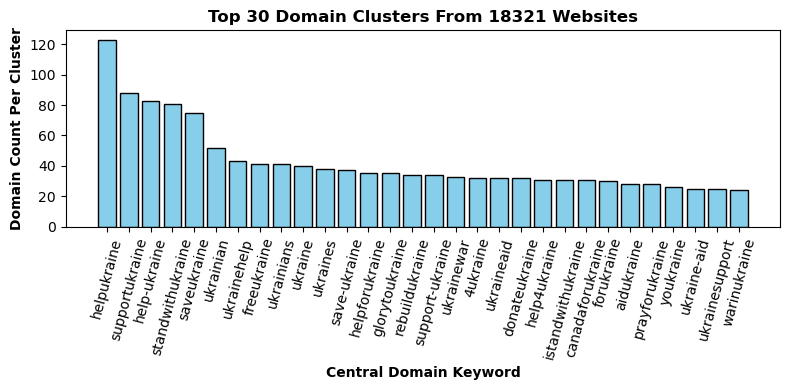

In [11]:
plot_domain_clusters(domains)

In [ ]:
df = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
df.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Parked Status,IPQS Unsafe,IPQS Status Code,IPQS Parking,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,0,False,200,False,False,False,False,False,False,0
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,1,False,200,False,False,False,False,True,False,55
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,0,False,200,False,False,False,False,False,False,0
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,0,False,200,False,False,False,False,True,False,55
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,0,True,200,False,False,False,True,True,False,91


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [67]:
df['Status Code'].value_counts()

Status Code
 200    1617
-1       420
 404      47
 403      13
 503       4
 500       4
 520       3
 401       2
 530       2
 521       2
 502       1
 418       1
 429       1
 423       1
Name: count, dtype: int64

In [68]:
df[(df['Status Code']==-1) & (df['Has Bank Related Keywords']==1)]

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Parked Status,IPQS Unsafe,IPQS Status Code,IPQS Parking,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score
382,45.47,1,1,0,0,2,2,68.50,27.50,0.0,...,0,False,200,True,False,False,False,True,False,99
392,47.84,0,1,0,0,2,2,28.00,13.00,0.0,...,0,False,200,True,False,False,False,True,False,99
411,45.51,1,1,0,0,2,2,69.00,28.00,0.0,...,0,False,200,True,False,False,False,True,False,99
698,446.23,0,1,1,1,1,70,58.46,41.05,0.0,...,0,False,200,False,False,False,False,False,False,0
774,970.66,0,1,0,1,2,11,43.27,16.07,0.0,...,0,False,200,False,False,False,False,False,False,0
908,595.79,0,1,0,0,49,5,47.80,41.85,0.0,...,0,False,200,False,False,False,False,False,False,0
991,87.33,1,1,0,0,1,10,78.40,37.45,0.0,...,0,False,200,False,False,False,False,True,False,55
1019,35.66,1,1,1,1,2,2,69.50,28.50,0.0,...,0,False,200,True,False,False,False,True,False,99
1262,52.82,0,1,0,0,2,2,28.00,13.00,0.0,...,0,False,200,True,False,False,False,True,False,99
1286,42.90,0,1,0,0,2,2,28.00,13.00,0.0,...,0,False,200,True,False,False,False,True,False,99


In [69]:
df[(df['Status Code']==-1) & (df['Has Crypto Related Keywords']==1)]

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Parked Status,IPQS Unsafe,IPQS Status Code,IPQS Parking,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score
698,446.23,0,1,1,1,1,70,58.46,41.05,0.0,...,0,False,200,False,False,False,False,False,False,0
1019,35.66,1,1,1,1,2,2,69.50,28.50,0.0,...,0,False,200,True,False,False,False,True,False,99
1409,34.77,1,1,1,1,2,2,71.00,30.00,0.0,...,0,False,200,True,False,False,False,True,False,99
1533,255.57,1,0,1,0,16,0,0.00,0.00,0.0,...,0,False,200,False,False,False,False,True,False,72


In [70]:
df[(df['Status Code']==-1) & (df['Has Card Related Keywords']==1)]

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Parked Status,IPQS Unsafe,IPQS Status Code,IPQS Parking,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score
698,446.23,0,1,1,1,1,70,58.46,41.05,0.0,...,0,False,200,False,False,False,False,False,False,0
774,970.66,0,1,0,1,2,11,43.27,16.07,0.0,...,0,False,200,False,False,False,False,False,False,0
1019,35.66,1,1,1,1,2,2,69.50,28.50,0.0,...,0,False,200,True,False,False,False,True,False,99
1409,34.77,1,1,1,1,2,2,71.00,30.00,0.0,...,0,False,200,True,False,False,False,True,False,99
2016,17.30,1,0,0,1,2,7,42.86,13.87,0.0,...,0,False,200,False,False,False,False,True,False,55


In [71]:
cluster1 = df[(df['Majority Voting Label']==0)]
cluster2 = df[(df['Majority Voting Label']==1)]
cluster3 = df[(df['Majority Voting Label']==2)]

In [72]:
from rapidfuzz import fuzz
import numpy as np
from sklearn.cluster import DBSCAN



def cluster_similar_strings(domains, similarity_threshold=95):
    """
    Cluster strings based on similarity using DBSCAN.

    Parameters:
    - domains: list of strings, the domains to cluster.
    - similarity_threshold: int, the similarity threshold for clustering (default: 90).

    Returns:
    - clusters: list of lists, where each sublist contains domains in the same cluster.
    """
    # Compute the similarity matrix
    n = len(domains)
    similarity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            similarity_matrix[i][j] = fuzz.ratio(domains[i], domains[j])

    # Convert similarity to distance (DBSCAN requires distance matrix)
    distance_matrix = 100 - similarity_matrix

    # Perform clustering with DBSCAN
    dbscan = DBSCAN(eps=100 - similarity_threshold, min_samples=1, metric='precomputed')
    labels = dbscan.fit_predict(distance_matrix)

    # Group domains by cluster labels
    clusters = {}
    for label, domain in zip(labels, domains):
        clusters.setdefault(label, []).append(domain)

    return list(clusters.values())

In [73]:
from collections import Counter

my_list = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
my_dict = Counter(my_list)
my_dict

Counter({4: 4, 3: 3, 2: 2, 1: 1})

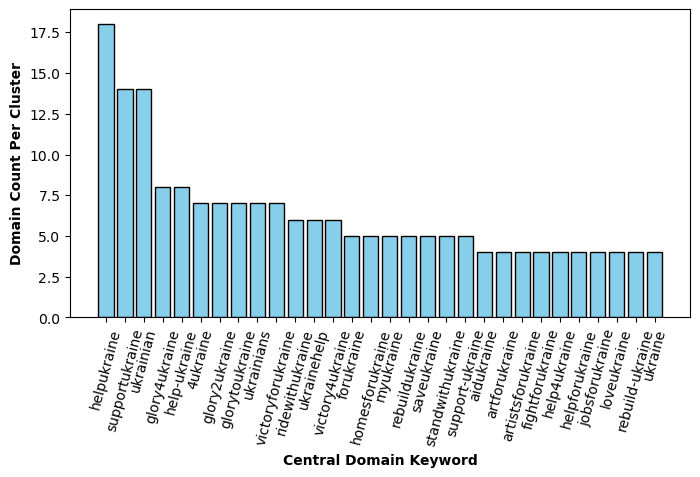

In [74]:
only_the_domain_name = []

for i in range(len(df)):
    only_the_domain_name.append(df['Domain'][i].replace('.'+df['TLD'][i],''))

# print(only_the_domain_name)

# clusters = cluster_similar_strings(only_the_domain_name)
clusters_dict = Counter(only_the_domain_name)
clusters = []
for i in clusters_dict:
    clusters.append([i]*clusters_dict[i])

# print(clusters)

clusters.sort(key=len, reverse=True)

X = []
Y = []

for i in range(30):
    clusters[i].sort()
    # print(len(clusters[i]), list(set(clusters[i])))
    X.append(list(set(clusters[i]))[0])
    Y.append(len(clusters[i]))

plt.figure(figsize=(8, 4))
plt.xticks(rotation=75)
plt.bar(X,Y,color='#87CEEB',edgecolor='black', linewidth=1)
plt.xlabel('Central Domain Keyword',fontweight='bold')
plt.ylabel("Domain Count Per Cluster",fontweight='bold')
plt.show()

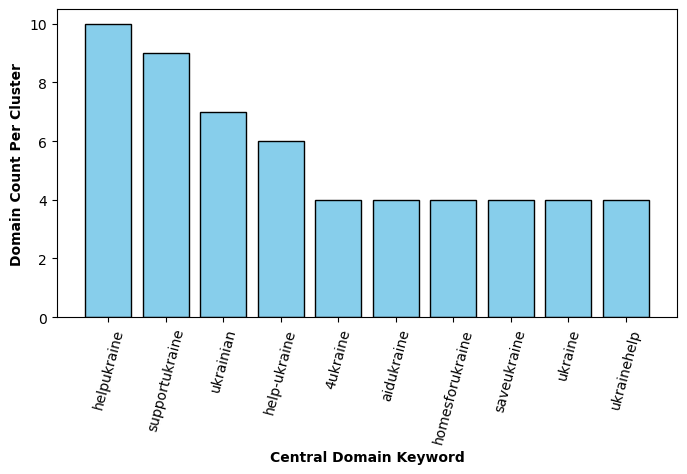

In [75]:
clusters_dict = Counter([only_the_domain_name[i] for i in df[(df['Majority Voting Label']==0)].index])
clusters = []
for i in clusters_dict:
    clusters.append([i]*clusters_dict[i])

# print(clusters)

clusters.sort(key=len, reverse=True)

X = []
Y = []

for i in range(10):
    clusters[i].sort()
    # print(len(clusters[i]), list(set(clusters[i])))
    X.append(list(set(clusters[i]))[0])
    Y.append(len(clusters[i]))

plt.figure(figsize=(8, 4))
plt.xticks(rotation=75)
plt.bar(X,Y,color='#87CEEB',edgecolor='black', linewidth=1)
plt.xlabel('Central Domain Keyword',fontweight='bold')
plt.ylabel("Domain Count Per Cluster",fontweight='bold')
plt.show()

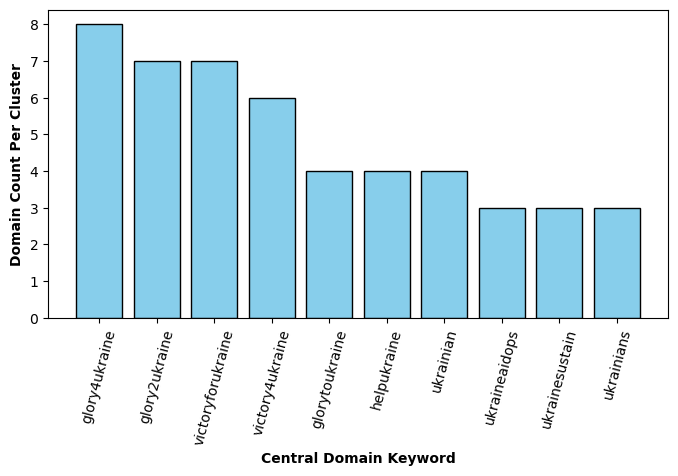

In [76]:
clusters_dict = Counter([only_the_domain_name[i] for i in df[(df['Majority Voting Label']==1)].index])
clusters = []
for i in clusters_dict:
    clusters.append([i]*clusters_dict[i])
# print(clusters)

clusters.sort(key=len, reverse=True)

X = []
Y = []

for i in range(10):
    clusters[i].sort()
    # print(len(clusters[i]), list(set(clusters[i])))
    X.append(list(set(clusters[i]))[0])
    Y.append(len(clusters[i]))

plt.figure(figsize=(8, 4))
plt.xticks(rotation=75)
plt.bar(X,Y,color='#87CEEB',edgecolor='black', linewidth=1)
plt.xlabel('Central Domain Keyword',fontweight='bold')
plt.ylabel("Domain Count Per Cluster",fontweight='bold')
plt.show()

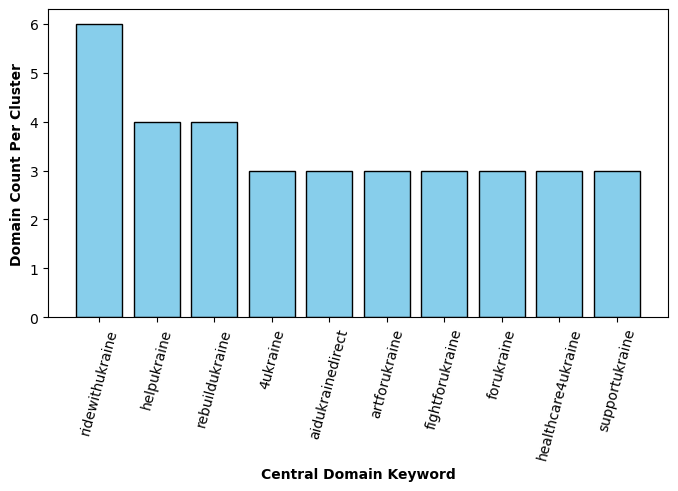

In [77]:
clusters_dict = Counter([only_the_domain_name[i] for i in df[(df['Majority Voting Label']==2)].index])
clusters = []
for i in clusters_dict:
    clusters.append([i]*clusters_dict[i])
# print(clusters)

clusters.sort(key=len, reverse=True)

X = []
Y = []

for i in range(10):
    clusters[i].sort()
    # print(len(clusters[i]), list(set(clusters[i])))
    X.append(list(set(clusters[i]))[0])
    Y.append(len(clusters[i]))

plt.figure(figsize=(8, 4))
plt.xticks(rotation=75)
plt.bar(X,Y,color='#87CEEB',edgecolor='black', linewidth=1)
plt.xlabel('Central Domain Keyword',fontweight='bold')
plt.ylabel("Domain Count Per Cluster",fontweight='bold')
plt.show()

In [78]:
ccTLD_list = pd.read_csv('../Data/ccTLD.csv',sep=r'\s+', engine='python')
ccTLD_list

,ccTLD,Country,DNSSEC,IDN
0,.ac,Ascension_Island,Yes,Yes
1,.ad,Andorra,Yes,No
2,.ae,United_Arab_Emirates,No,No
3,.af,Afghanistan,Yes,No
4,.ag,Antigua_and_Barbuda,Yes,No
...,...,...,...,...
254,.yu,Yugoslavia,No,No
255,.za,South-Africa,No,No
256,.zm,Zambia,No,No
257,.zr,Zaire,No,No


In [79]:
for i in range(len(ccTLD_list)):
    ccTLD_list['ccTLD'][i] = ccTLD_list['ccTLD'][i].replace('.','')

In [80]:
ccTLD_list['ccTLD']

0      ac
1      ad
2      ae
3      af
4      ag
       ..
254    yu
255    za
256    zm
257    zr
258    zw
Name: ccTLD, Length: 259, dtype: object

In [81]:
def ccTLD_count(cluster):
    all_tld = cluster['TLD']
    ccTLD_cnt = {}
    for j in all_tld:
        for i in ccTLD_list['ccTLD']:
            if i in j.split('.'):
                if i in ccTLD_cnt:
                    ccTLD_cnt[i]+=1
                else:
                    ccTLD_cnt[i]=1
                break
    return ccTLD_cnt

In [82]:
print(ccTLD_count(cluster1))

{'fr': 12, 'ca': 16, 'uk': 16, 'pl': 7, 'de': 93, 'ch': 24, 'co': 27, 'dk': 10, 'eu': 24, 'at': 11, 'cz': 3, 'ua': 5, 'se': 5, 'io': 6, 'ie': 1, 'nl': 15, 'us': 8, 'me': 3, 'pt': 1, 'is': 1, 'lt': 2, 'lu': 1, 'lv': 1, 'nu': 1, 'au': 4, 'ro': 1, 'hu': 2, 'it': 5, 'be': 5, 'fi': 2, 'ru': 1, 'jp': 2, 'am': 1, 'nz': 1, 'ps': 1, 'si': 1, 'in': 1, 'hk': 1}


In [83]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_n_dicts(dict1, dict2, dict3, n, cost):
    """
    Plot top n values from three dictionaries with different colors and display the registration cost
    for each ccTLD as x-tick labels.
    
    Parameters:
    - dict1, dict2, dict3: Dictionaries containing the data to compare.
    - n: Number of top items to plot.
    - cost: List of costs for each ccTLD.
    """
    # Sort the dictionaries by value and get the top n keys
    top_keys1 = sorted(dict1, key=dict1.get, reverse=True)[:n]
    top_keys2 = sorted(dict2, key=dict2.get, reverse=True)[:n]
    top_keys3 = sorted(dict3, key=dict3.get, reverse=True)[:n]

    # Get the corresponding values for each dictionary
    values1 = [dict1[key] for key in top_keys1]
    values2 = [dict2[key] for key in top_keys2]
    values3 = [dict3[key] for key in top_keys3]

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Set bar width and position
    bar_width = 0.25
    index = np.arange(n)

    # Plot bars for each dictionary with different colors
    bars1 = ax.bar(index, values1, bar_width, color='lightgreen', label='cluster 1')
    bars2 = ax.bar(index + bar_width, values2, bar_width, color='salmon', label='cluster 2')
    bars3 = ax.bar(index + 2 * bar_width, values3, bar_width, color='skyblue', label='cluster 3')

    # Set x-ticks with cost values
    x_tick_labels = [f"{key}\n${cost[i]:.2f}" for i, key in enumerate(top_keys1)]
    ax.set_xticks(index + bar_width)  # Set the position of x-ticks
    ax.set_xticklabels(x_tick_labels, rotation=45)  # Set the labels to include cost

    # Add labels and title
    ax.set_xlabel('Country Code TLD with one year registration cost')
    ax.set_ylabel('Count')
    
    # Add a legend
    ax.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()


In [84]:
import matplotlib.pyplot as plt

def plot_line_with_markers(dict1, dict2, dict3, n):
    """
    Plot line plots with markers for top n values from three dictionaries.
    Annotate each point with its corresponding key.
    
    Parameters:
    - dict1, dict2, dict3: Dictionaries containing the data to compare.
    - n: Number of top items to plot.
    """
    # Sort the dictionaries by value and get the top n keys
    top_keys1 = sorted(dict1, key=dict1.get, reverse=True)[:n]
    top_keys2 = sorted(dict2, key=dict2.get, reverse=True)[:n]
    top_keys3 = sorted(dict3, key=dict3.get, reverse=True)[:n]

    # Get the corresponding values for each dictionary
    values1 = [dict1[key] for key in top_keys1]
    values2 = [dict2[key] for key in top_keys2]
    values3 = [dict3[key] for key in top_keys3]

    # Plot lines with markers for each dictionary
    plt.plot(top_keys1, values1, label='Dict 1', marker='o', color='green', linestyle='-', markersize=8)
    plt.plot(top_keys2, values2, label='Dict 2', marker='s', color='red', linestyle='-', markersize=8)
    plt.plot(top_keys3, values3, label='Dict 3', marker='^', color='blue', linestyle='-', markersize=8)

    # Annotate each point with its key
    for i, key in enumerate(top_keys1):
        plt.text(top_keys1[i], values1[i], key, color='green', fontsize=10, ha='center', va='bottom')
    for i, key in enumerate(top_keys2):
        plt.text(top_keys2[i], values2[i], key, color='red', fontsize=10, ha='center', va='bottom')
    for i, key in enumerate(top_keys3):
        plt.text(top_keys3[i], values3[i], key, color='blue', fontsize=10, ha='center', va='bottom')

    # Add labels and title
    plt.xlabel('Top n Keys')
    plt.ylabel('Values')
    plt.title(f'Top {n} Values from Three Dictionaries')
    
    plt.xticks([])
    # Add a legend
    plt.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()


In [85]:
cluster1_cctld_cnt = ccTLD_count(cluster1)
cluster2_cctld_cnt = ccTLD_count(cluster2)
cluster3_cctld_cnt = ccTLD_count(cluster3)

print('total ccTLD occurance', sum(cluster1_cctld_cnt.values())+sum(cluster2_cctld_cnt.values())+sum(cluster3_cctld_cnt.values()))

total ccTLD occurance 632


In [86]:
print('cluster1',dict(sorted(cluster1_cctld_cnt.items(), key=lambda item: item[1], reverse=True)))
print('cluster2',dict(sorted(cluster2_cctld_cnt.items(), key=lambda item: item[1], reverse=True)))
print('cluster3',dict(sorted(cluster3_cctld_cnt.items(), key=lambda item: item[1], reverse=True)))

cluster1 {'de': 93, 'co': 27, 'ch': 24, 'eu': 24, 'ca': 16, 'uk': 16, 'nl': 15, 'fr': 12, 'at': 11, 'dk': 10, 'us': 8, 'pl': 7, 'io': 6, 'ua': 5, 'se': 5, 'it': 5, 'be': 5, 'au': 4, 'cz': 3, 'me': 3, 'lt': 2, 'hu': 2, 'fi': 2, 'jp': 2, 'ie': 1, 'pt': 1, 'is': 1, 'lu': 1, 'lv': 1, 'nu': 1, 'ro': 1, 'ru': 1, 'am': 1, 'nz': 1, 'ps': 1, 'si': 1, 'in': 1, 'hk': 1}
cluster2 {'de': 48, 'co': 11, 'eu': 9, 'us': 9, 'fr': 6, 'uk': 5, 'ca': 4, 'nl': 4, 'ch': 2, 'at': 2, 'io': 2, 'au': 1, 'be': 1, 'ru': 1, 'me': 1, 'pw': 1, 'mt': 1, 'no': 1, 'gr': 1, 'tv': 1, 'pl': 1, 'ro': 1}
cluster3 {'de': 49, 'co': 16, 'eu': 16, 'uk': 15, 'ch': 15, 'fr': 14, 'be': 11, 'nl': 11, 'pl': 9, 'ca': 7, 'us': 5, 'dk': 4, 'at': 4, 'jp': 4, 'cz': 2, 'fi': 2, 'me': 2, 'ro': 2, 'ie': 2, 'ua': 2, 'au': 2, 'se': 1, 'ge': 1, 'io': 1, 'ee': 1}


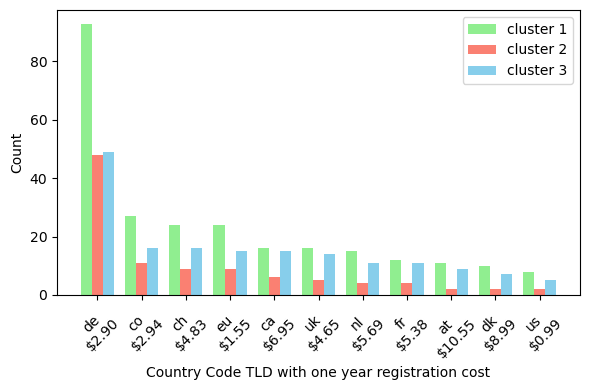

In [87]:
cost = [2.90,2.94,4.83,1.55,6.95,4.65,5.69,5.38,10.55,8.99,0.99] #one year registration cost for the [de,co,ch,eu,ca,uk,nl,fr,at,dk,us] from https://tld-list.com/
plot_top_n_dicts(cluster1_cctld_cnt,cluster2_cctld_cnt,cluster3_cctld_cnt,11,cost)

In [88]:
# plot_line_with_markers(cluster1_cctld_cnt,cluster2_cctld_cnt,cluster3_cctld_cnt,20)

In [89]:
# IPQS_data = pd.read_csv('../Data/2118_IPQS_Analysis_Data.csv')
# print(len(IPQS_data))
# IPQS_data.head()

In [90]:
# sorted_IPQS_data = df[['Searched_URL']].rename(columns={'Searched_URL': 'url'}).merge(IPQS_data, on='url', how='left')
# sorted_IPQS_data.head()

In [91]:
# df['IPQS Unsafe'] = sorted_IPQS_data['unsafe']
# df['IPQS Status Code'] = sorted_IPQS_data['status_code']
# df['IPQS Parking'] = sorted_IPQS_data['parking']
# df['IPQS Spamming'] = sorted_IPQS_data['spamming']
# df['IPQS malware'] = sorted_IPQS_data['malware']
# df['IPQS Phishing'] = sorted_IPQS_data['phishing']
# df['IPQS Suspicious'] = sorted_IPQS_data['suspicious']
# df['IPQS Adult'] = sorted_IPQS_data['adult']
# df['IPQS Risk Score'] = sorted_IPQS_data['risk_score']

In [92]:
# df.info()

In [93]:
# df.to_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv',index=None)

In [94]:
def IPQS_STAT(column):
    # print('---------------------------------------')
    print(column,len(cluster1[cluster1[column]==True]))
    print(column,len(cluster2[cluster2[column]==True]))
    print(column,len(cluster3[cluster3[column]==True]))
    # print('---------------------------------------')
    print('\n\n')

In [95]:
IPQS_STAT('IPQS Unsafe')
IPQS_STAT('IPQS Parking')
IPQS_STAT('IPQS Spamming')
IPQS_STAT('IPQS malware')
IPQS_STAT('IPQS Phishing')
IPQS_STAT('IPQS Suspicious')
IPQS_STAT('IPQS Adult')



# print('---------------------------------------')
print('IPQS Risk Score',len(cluster1[cluster1['IPQS Risk Score']>74]))
print('IPQS Risk Score',len(cluster2[cluster2['IPQS Risk Score']>74]))
print('IPQS Risk Score',len(cluster3[cluster3['IPQS Risk Score']>74]))
# print('---------------------------------------')
print('\n\n')

IPQS Unsafe 4
IPQS Unsafe 0
IPQS Unsafe 4



IPQS Parking 30
IPQS Parking 129
IPQS Parking 56



IPQS Spamming 7
IPQS Spamming 5
IPQS Spamming 5



IPQS malware 2
IPQS malware 0
IPQS malware 3



IPQS Phishing 4
IPQS Phishing 0
IPQS Phishing 4



IPQS Suspicious 522
IPQS Suspicious 307
IPQS Suspicious 261



IPQS Adult 7
IPQS Adult 9
IPQS Adult 12



IPQS Risk Score 154
IPQS Risk Score 267
IPQS Risk Score 118





In [96]:
# import requests

# endpoint = "https://checkurl.phishtank.com/checkurl/"
# url = "https://paxfullogin.github.io/paxful-login/"
# response = requests.post(endpoint, data={"url": url, "format": "json"})
# print(response)

In [97]:
VT_result = {}

with open('../Data/VT_log.txt') as f:
    lines = [line.rstrip() for line in f]


for i in range(len(lines)):

    # print(df['Domain'][i], lines[i][lines[i].index('URL: ')+5:lines[i].index('Result')-2])

    if df['Domain'][i] not in lines[i][lines[i].index('URL: ')+5:lines[i].index('Result')-2]:
        print('missmatched URL!', df['Domain'][i], lines[i][lines[i].index('URL: ')+5:lines[i].index('Result')-2])

    if lines[i][lines[i].index('Result:')+8:lines[i].index('Result:')+8+5] == 'Error':
        VT_result[df['Domain'][i]] = {}
        # print({})
        continue
    # print(ast.literal_eval(lines[i][lines[i].index('Result:')+8:])['data']['attributes']['last_analysis_stats'])
    VT_result[df['Domain'][i]] = ast.literal_eval(lines[i][lines[i].index('Result:')+8:])['data']['attributes']['last_analysis_stats']

# print(lines[5][lines[5].index('Result:'):])

# json.loads(lines[1][lines[1].index('Result:')+8:])

In [98]:

print(lines[1][lines[1].index('URL: ')+5:lines[1].index('Result')-2])
# print(ast.literal_eval(lines[1][lines[1].index('Result:')+8:])['data']['attributes'])

https://www.1to1ukrainemuseums.org 


In [99]:
VT_result['1to1ukrainemuseums.org']

{'malicious': 0,
 'suspicious': 0,
 'undetected': 12,
 'harmless': 83,
 'timeout': 0}

In [100]:
i=0
mal, sus, clean, undetected = 0,0,0,0
for kkey in VT_result:

    if len(VT_result[kkey]) == 0:
        if df['Majority Voting Label'][i]==0:
            undetected += 1
        continue

    if df['Majority Voting Label'][i]==0 and VT_result[kkey]['malicious']:
        mal += 1
    if df['Majority Voting Label'][i]==0 and VT_result[kkey]['suspicious']:
        sus += 1
    elif  df['Majority Voting Label'][i]==0 and (VT_result[kkey]['malicious']==0 and VT_result[kkey]['suspicious']==0):
        clean += 1
    i+=1

print(mal, sus, clean, undetected)

34 19 339 772


In [101]:
i=0
mal, sus, clean, undetected = 0,0,0,0
for kkey in VT_result:

    if len(VT_result[kkey]) == 0:
        if df['Majority Voting Label'][i]==1:
            undetected += 1
        continue

    if df['Majority Voting Label'][i]==1 and VT_result[kkey]['malicious']:
        mal += 1
    if df['Majority Voting Label'][i]==1 and VT_result[kkey]['suspicious']:
        sus += 1
    elif  df['Majority Voting Label'][i]==1 and (VT_result[kkey]['malicious']==0 and VT_result[kkey]['suspicious']==0):
        clean += 1
    i+=1

print(mal, sus, clean, undetected)

13 5 99 250


In [102]:
i=0
mal, sus, clean, undetected = 0,0,0,0
for kkey in VT_result:

    if len(VT_result[kkey]) == 0:
        if df['Majority Voting Label'][i]==2:
            undetected += 1
        continue

    if df['Majority Voting Label'][i]==2 and VT_result[kkey]['malicious']:
        mal += 1
    if df['Majority Voting Label'][i]==2 and VT_result[kkey]['suspicious']:
        sus += 1
    elif  df['Majority Voting Label'][i]==2 and (VT_result[kkey]['malicious']==0 and VT_result[kkey]['suspicious']==0):
        clean += 1
    i+=1

print(mal, sus, clean, undetected)

20 2 178 392


In [103]:
#adding the vt label in the final data file

i=0
mal, sus, clean, undetected = [0]*len(df),[0]*len(df),[0]*len(df),[0]*len(df)
for kkey in VT_result:

    if len(VT_result[kkey]) == 0:
        undetected[i]=1
        continue

    elif VT_result[kkey]['malicious']:
        mal[i]=1
    elif VT_result[kkey]['suspicious']:
        sus[i]=1
    elif  (VT_result[kkey]['malicious']==0 and VT_result[kkey]['suspicious']==0):
        clean[i]=1
    i+=1

print(mal, sus, clean, undetected)

[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [104]:
ipqs_VT_agree = 0
for i in range(len(df)):
    if df['IPQS_Flag'][i] and (mal[i] or sus[i]):
        ipqs_VT_agree+=1
        # print(df['Majority Voting Label'][i])

ipqs_VT_agree

19

In [105]:
parked_vt = 0
for i in range(len(df)):
    if df['IPQS Parking'][i] and (clean[i]):
        parked_vt+=1
        # print(df['Majority Voting Label'][i])

parked_vt

57

In [106]:
parked_vt = 0
for i in range(len(df)):
    if df['Parked Status'][i] and (clean[i]):
        parked_vt+=1
        # print(df['Majority Voting Label'][i])

parked_vt

84

In [108]:
df['VT Malicious'] = mal
df['VT Suspicious'] = sus
df['VT Harmless'] = clean
df['VT NoData Available'] = undetected

In [ ]:
# df.to_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv', index=None)